# Hands-On Task Module 2

**Nama:** Jonathan Lewie
**NIM:** 13525136

Notebook ini adalah pengerjaan Hands-On Task Module 2, analisis dataset MPG (fuel efficiency kendaraan) menggunakan NumPy, Pandas, Seaborn, dan Matplotlib.

## Stage 1, Inspection and Data Cleaning

In [55]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

df = sns.load_dataset('mpg')

print("Shape:", df.shape)
print()
print("Dtypes:")
print(df.dtypes)
print()
print("Missing values per column:")
print(df.isna().sum())

Shape: (398, 9)

Dtypes:
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin              str
name                str
dtype: object

Missing values per column:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


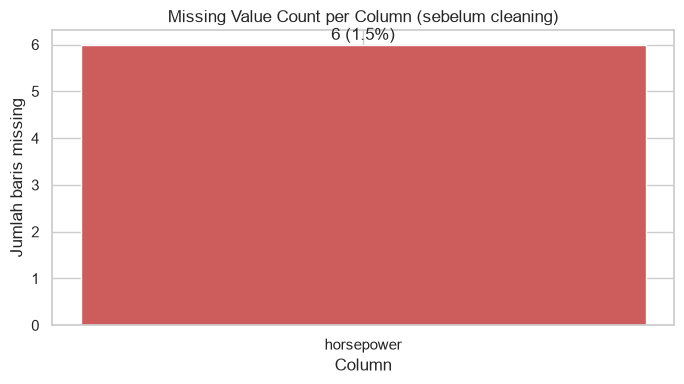

In [56]:
missing_counts = df.isna().sum()
missing_counts = missing_counts[missing_counts > 0]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(missing_counts.index, missing_counts.values, color='indianred')
ax.set_title('Missing Value Count per Column (sebelum cleaning)')
ax.set_xlabel('Column')
ax.set_ylabel('Jumlah baris missing')
for i, v in enumerate(missing_counts.values):
    pct = v / len(df) * 100
    ax.text(i, v + 0.1, f'{v} ({pct:.1f}%)', ha='center')
plt.tight_layout()
plt.show()

Yang missing cuma `horsepower`, 6 baris dari 398 (~1.5%). Jadi sebenernya drop atau imputasi median dua-duanya masih masuk akal buat kasus ini.

saya akhirnya pilih drop aja karena proporsinya kecil banget jadi kehilangan 6 baris nggak bakal ngubah distribusi secara berarti, sementara kalau diimputasi menggunakan median, nilai yang dimasukin itu nggak nyambung ke kondisi mesin mobil yang sebenarnya (`horsepower` kan fitur mekanis, korelasinya kuat sama `displacement` dan `weight`, bisa dicek di correlation matrix nanti), jadi berpotensi nambah noise ke fitur yang justru mau dianalisis dalam-dalam di Stage 2 dan dipakai buat hue di scatter plot.

Threshold pribadi saya adalah kalau missingnya di atas ~10% baru mikir dua kali buat drop, di bawah itu masih aman.

In [57]:
df_clean = df.dropna(subset=['horsepower']).reset_index(drop=True)
print("Shape sebelum drop:", df.shape)
print("Shape sesudah drop:", df_clean.shape)
print("Baris yang kebuang:", df.shape[0] - df_clean.shape[0])

Shape sebelum drop: (398, 9)
Shape sesudah drop: (392, 9)
Baris yang kebuang: 6


### Summary table menggunakan NumPy

In [58]:
def summarize_column(arr):
    arr = np.asarray(arr, dtype=float)
    mean = np.mean(arr)
    median = np.median(arr)
    std = np.std(arr, ddof=1)
    q1, q3 = np.percentile(arr, [25, 75])
    iqr = q3 - q1
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr
    outlier_count = int(np.sum((arr < lower_fence) | (arr > upper_fence)))
    return mean, median, std, iqr, outlier_count

numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

rows = []
for col in numeric_cols:
    mean, median, std, iqr, n_out = summarize_column(df_clean[col].to_numpy())
    rows.append({
        'feature': col,
        'mean': round(mean, 2),
        'median': round(median, 2),
        'std': round(std, 2),
        'IQR': round(iqr, 2),
        'outlier_count': n_out
    })

summary_table = pd.DataFrame(rows).set_index('feature')
summary_table

,mean,median,std,IQR,outlier_count
feature,,,,,
mpg,23.45,22.75,7.81,12.00,0
cylinders,5.47,4.00,1.71,4.00,0
displacement,194.41,151.00,104.64,170.75,0
horsepower,104.47,93.50,38.49,51.00,10
weight,2977.58,2803.50,849.40,1389.50,0
acceleration,15.54,15.50,2.76,3.25,11
model_year,75.98,76.00,3.68,6.00,0


`horsepower` dan `acceleration` yang punya outlier paling banyak (10 dan 11), fitur lain nol. Handbook Module 2 bagian "Outliers Are Not Always Noise" bedain dua jenis outlier yaitu data error (nilai yang mustahil secara domain) vs valid extreme value (nilai ekstrem tapi memang nyata). Kasus di sini kemungkinan besar valid extreme value, mobil sport/performance yang wajar punya horsepower atau akselerasi tinggi, bukan error input, meski saya belum cek satu-satu row mana yang ke flag, jadi ini masih dugaan berdasarkan pola umum.

## Stage 2, Statistical Analysis with NumPy

In [59]:
feature_cols = ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']
X = df_clean[feature_cols].to_numpy()
X_z = (X - X.mean(axis=0)) / X.std(axis=0)

print("Mean tiap kolom setelah standardisasi (harus ~0):")
print(X_z.mean(axis=0).round(6))
print("\nStd tiap kolom setelah standardisasi (harus ~1):")
print(X_z.std(axis=0).round(6))

Mean tiap kolom setelah standardisasi (harus ~0):
[ 0. -0. -0. -0.  0.]

Std tiap kolom setelah standardisasi (harus ~1):
[1. 1. 1. 1. 1.]


In [60]:
corr_matrix = np.corrcoef(X, rowvar=False)
corr_df = pd.DataFrame(corr_matrix, index=feature_cols, columns=feature_cols)
corr_df.round(3)

,mpg,displacement,horsepower,weight,acceleration
mpg,1.000,-0.805,-0.778,-0.832,0.423
displacement,-0.805,1.000,0.897,0.933,-0.544
horsepower,-0.778,0.897,1.000,0.865,-0.689
weight,-0.832,0.933,0.865,1.000,-0.417
acceleration,0.423,-0.544,-0.689,-0.417,1.000


### Interpretasi correlation matrix

Ngecek pairwise correlation di luar diagonal. Soal (a) nanya "korelasi positif terkuat" tanpa nyebut harus sama `mpg`, jadi saya baca itu sebagai korelasi positif terkuat di seluruh matriks (beda sama poin (b) yang eksplisit nyebut "terhadap mpg"):

- **(a) Korelasi positif terkuat secara keseluruhan:** `displacement` dan `weight`, r = 0.933, masuk akal secara mekanis, mesin yang lebih besar biasanya dipasang di mobil yang bodinya juga lebih berat.
- **(b) Korelasi negatif terkuat terhadap `mpg`:** `mpg` dan `weight`, r = -0.832. Mobil yang lebih berat butuh lebih banyak energi buat gerak, jadi lebih boros.
- **(c) Pasangan input feature paling berkorelasi (potensi multikolinearitas):** sama seperti (a), `displacement`-`weight` (0.933), disusul `displacement`-`horsepower` (0.897) dan `horsepower`-`weight` (0.865). Handbook nyebut eksplisit kalau korelasi tinggi antar-input-feature (multicollinearity) "can be problematic for some models because they carry redundant information", tiga fitur ini persis kasus itu, jadi kalau dipakai bareng sebagai input regresi linear perlu hati-hati.

In [61]:
mean_hp = df_clean['horsepower'].mean()
mean_weight_all = df_clean['weight'].mean()

above_avg_hp_mask = df_clean['horsepower'].to_numpy() > mean_hp
avg_weight_above_hp = df_clean.loc[above_avg_hp_mask, 'weight'].mean()

abs_diff = abs(avg_weight_above_hp - mean_weight_all)

print(f"Mean horsepower dataset: {mean_hp:.2f}")
print(f"Jumlah mobil dengan horsepower di atas rata-rata: {above_avg_hp_mask.sum()} dari {len(df_clean)}")
print(f"Rata-rata weight dataset: {mean_weight_all:.2f}")
print(f"Rata-rata weight mobil dengan horsepower di atas rata-rata: {avg_weight_above_hp:.2f}")
print(f"Selisih absolut: {abs_diff:.2f}")

Mean horsepower dataset: 104.47
Jumlah mobil dengan horsepower di atas rata-rata: 148 dari 392
Rata-rata weight dataset: 2977.58
Rata-rata weight mobil dengan horsepower di atas rata-rata: 3815.49
Selisih absolut: 837.91


Mobil dengan horsepower di atas rata-rata cenderung juga lebih berat, selisihnya sekitar 838 lbs dibanding rata-rata weight keseluruhan dataset. Konsisten sama korelasi horsepower-weight (0.865) yang barusan dihitung, jadi bukan kebetulan, masuk akal juga secara mekanis, mesin yang lebih bertenaga biasanya lebih besar dan berat, dan biasanya dipasang di body mobil yang juga lebih besar.

## Stage 3, Visualisation

### Plot 1: MPG Distribution

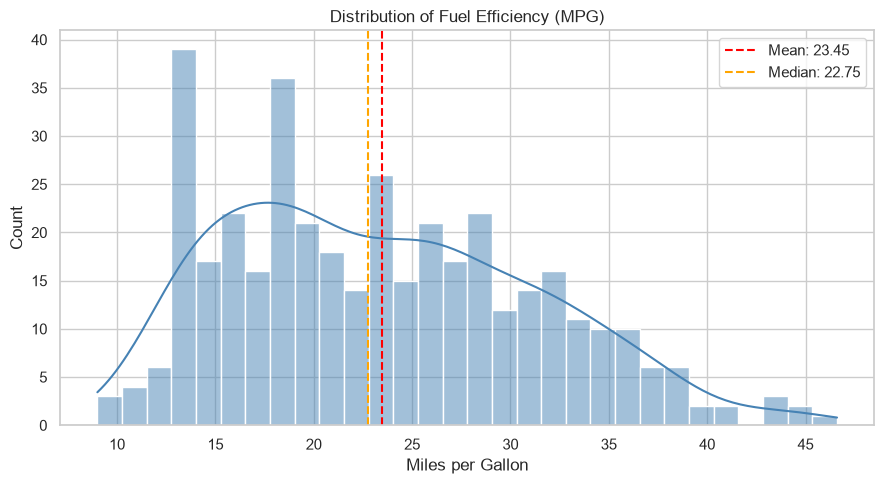

Mean: 23.45, Median: 22.75
Selisih mean-median: 0.70


In [62]:
mean_mpg = df_clean['mpg'].mean()
median_mpg = df_clean['mpg'].median()

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(df_clean['mpg'], bins=30, kde=True, ax=ax, color='steelblue')
ax.axvline(mean_mpg, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_mpg:.2f}')
ax.axvline(median_mpg, color='orange', linestyle='--', linewidth=1.5, label=f'Median: {median_mpg:.2f}')
ax.set_title('Distribution of Fuel Efficiency (MPG)')
ax.set_xlabel('Miles per Gallon')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean: {mean_mpg:.2f}, Median: {median_mpg:.2f}")
print(f"Selisih mean-median: {mean_mpg - median_mpg:.2f}")

Mean (23.45) sedikit lebih besar dari median (22.75), selisihnya cuma 0.7. Ini nunjukin distribusi mpg agak right-skewed, tapi ringan, bukan skew ekstrem. Ada beberapa mobil dengan mpg tinggi (mobil kecil/irit) yang naikin mean sedikit di atas median, tapi bentuknya masih relatif mendekati simetris.

### Plot 2: Origin Comparison (Box + Violin)

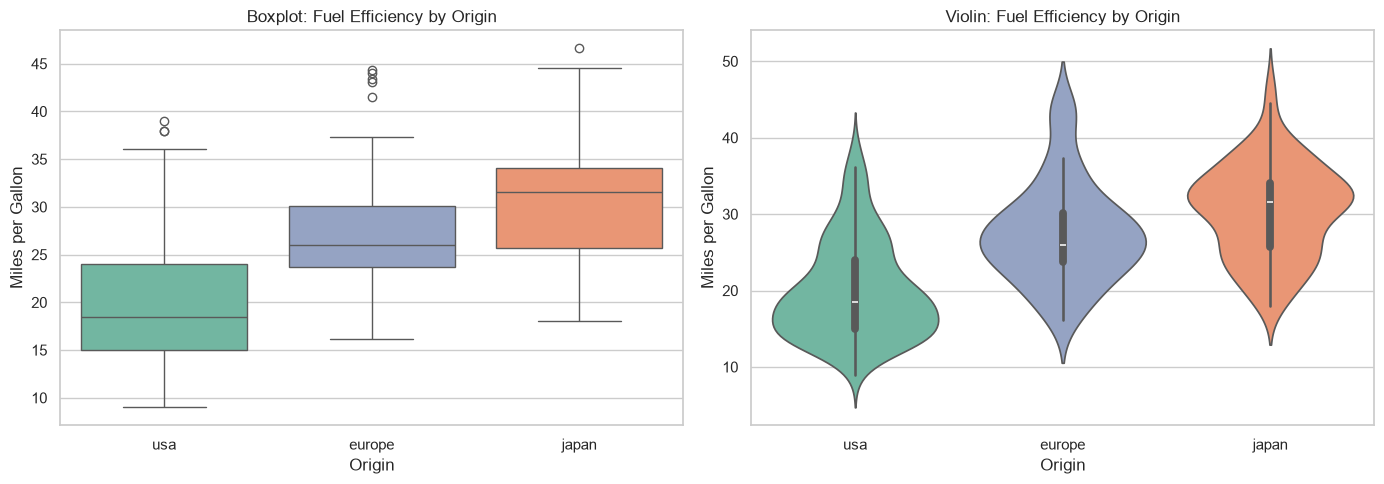

         mean  median   std
origin                     
europe  27.60    26.0  6.58
japan   30.45    31.6  6.09
usa     20.03    18.5  6.44


In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_clean, x='origin', y='mpg', hue='origin', palette='Set2', order=['usa', 'europe', 'japan'], legend=False, ax=axes[0])
axes[0].set_title('Boxplot: Fuel Efficiency by Origin')
axes[0].set_xlabel('Origin')
axes[0].set_ylabel('Miles per Gallon')

sns.violinplot(data=df_clean, x='origin', y='mpg', hue='origin', palette='Set2', order=['usa', 'europe', 'japan'], legend=False, ax=axes[1])
axes[1].set_title('Violin: Fuel Efficiency by Origin')
axes[1].set_xlabel('Origin')
axes[1].set_ylabel('Miles per Gallon')

plt.tight_layout()
plt.show()

print(df_clean.groupby('origin')['mpg'].agg(['mean', 'median', 'std']).round(2))

Jepang punya mean mpg tertinggi (30.45), disusul Eropa (27.60), USA paling boros (20.03). Dari stdnya, Jepang (6.09) dan Eropa (6.58) mirip dan relatif konsisten, USA juga stdnya nggak jauh beda (6.44) tapi rentang mpgnya jauh lebih rendah.

Violin plot ngasih info tambahan yang boxplot nggak kasih, distribusi USA keliatan lebih lebar dan kayak ada dua gerombolan density (agak bimodal). Ini mirip sama contoh bimodal yang disebut di Handbook Module 2 (histogram dua puncak = campuran dua populasi berbeda), tapi saya belum cek langsung mobil mana aja yang bikin dua puncak itu, jadi ini dugaan aja: kemungkinan campuran compact car sama mobil besar (V8) yang sama-sama diproduksi USA. Yang jelas boxplot doang nggak nangkep pola ini karena cuma nunjukin quartile, bukan bentuk density-nya.

### Plot 3: Weight vs MPG Relationship

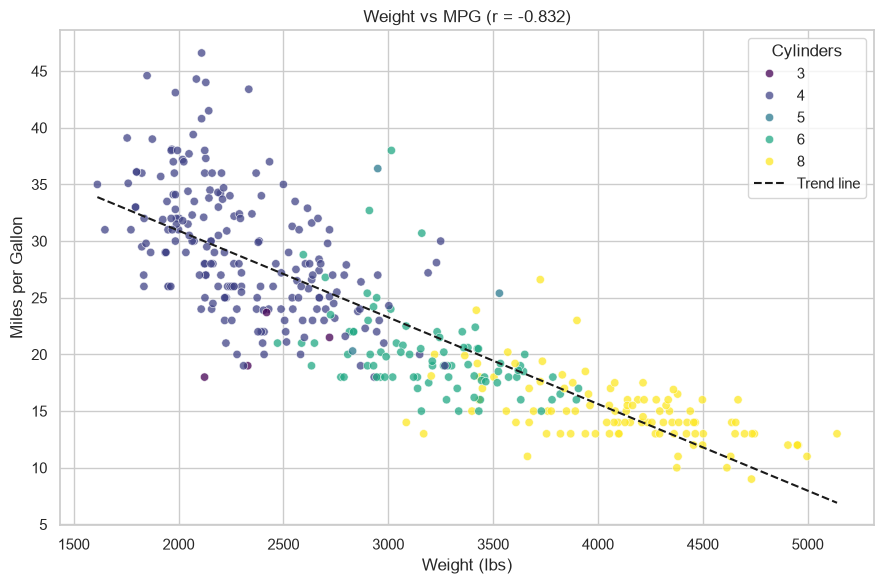

In [64]:
corr_weight_mpg = df_clean['weight'].corr(df_clean['mpg'])

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=df_clean, x='weight', y='mpg', hue='cylinders', palette='viridis', alpha=0.75, ax=ax)

z = np.polyfit(df_clean['weight'], df_clean['mpg'], 1)
p = np.poly1d(z)
xline = np.linspace(df_clean['weight'].min(), df_clean['weight'].max(), 100)
ax.plot(xline, p(xline), 'k--', linewidth=1.5, label='Trend line')

ax.set_title(f'Weight vs MPG (r = {corr_weight_mpg:.3f})')
ax.set_xlabel('Weight (lbs)')
ax.set_ylabel('Miles per Gallon')
ax.legend(title='Cylinders')
plt.tight_layout()
plt.show()

Hubungan weight vs mpg jelas negatif (r = -0.832), makin berat mobilnya makin boros. Hue cylinders nunjukin pola tambahan: mobil dengan cylinder lebih banyak (6-8) cenderung ngumpul di area weight tinggi/mpg rendah, mobil 4-cylinder dominan di weight rendah/mpg tinggi. Jadi cylinders dan weight kemungkinan sama-sama proxy dari "ukuran mobil".

### Plot 4: Correlation Heatmap

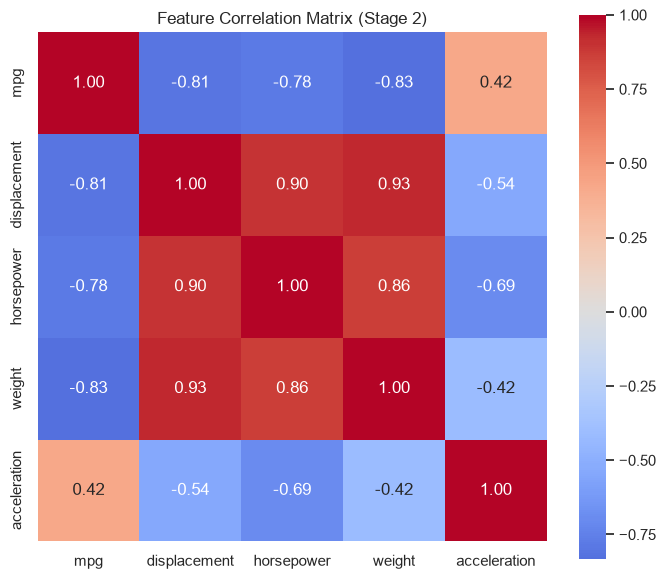

In [65]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, ax=ax)
ax.set_title('Feature Correlation Matrix (Stage 2)')
plt.tight_layout()
plt.show()

Pola multikolinearitas paling keliatan di segitiga `displacement`-`horsepower`-`weight`, ketiganya merah tua (korelasi di atas 0.86 semua). Masuk akal, ketiganya sama-sama ngerepresentasiin "ukuran/kapasitas mesin" cuma dari sisi yang beda-beda. Ini yang di handbook disebut multicollinearity, tiga fitur ini bawa informasi yang redundant, jadi kalau dipaksa dipakai bertiga sekaligus di linear regression kemungkinan salah satunya perlu di-drop atau digabung (misalnya lewat PCA kayak di Bonus 2 nanti).

### Plot 5: Pair Plot

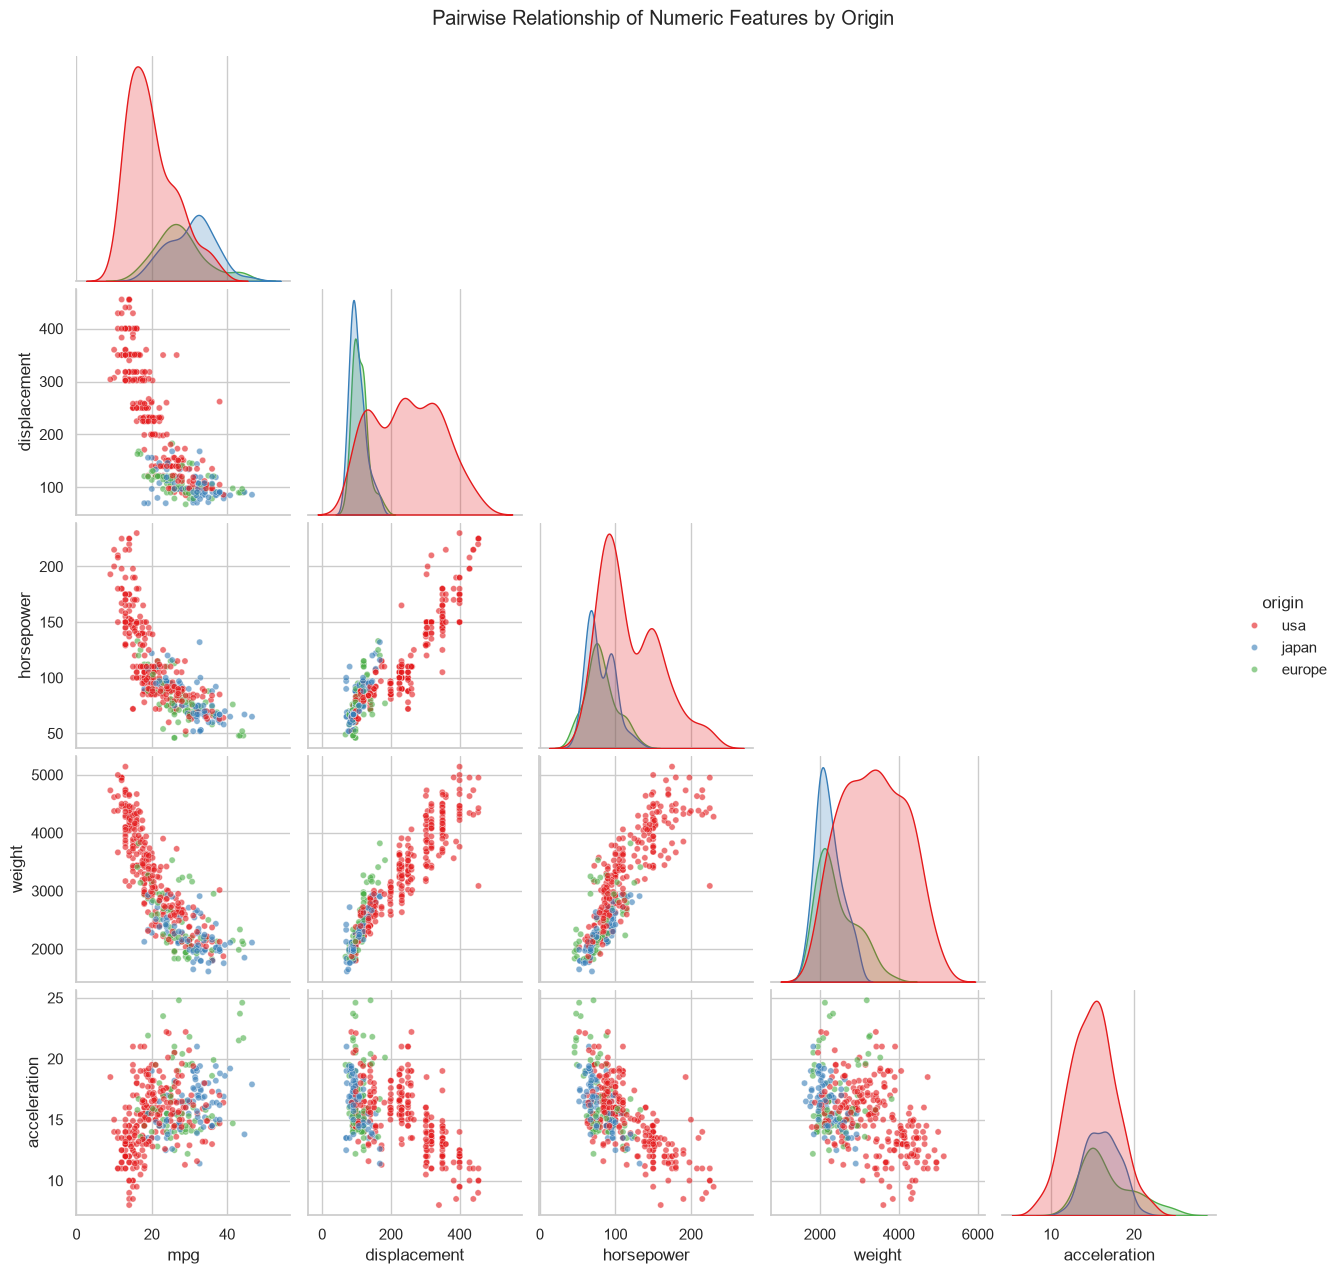

In [66]:
pair_data = df_clean[feature_cols + ['origin']]
g = sns.pairplot(pair_data, hue='origin', palette='Set1', corner=True, plot_kws={'alpha': 0.6, 's': 20})
g.fig.suptitle('Pairwise Relationship of Numeric Features by Origin', y=1.02)
plt.show()

Pair plot ini ngerangkum semua scatter pairwise dalam satu gambar, jadi kelihatan pola yang mungkin kelewat kalau cuma liat satu pasangan fitur (kayak weight-mpg di Plot 3). `displacement`, `horsepower`, dan `weight` sama-sama punya bentuk scatter yang mirip terhadap `mpg` (negatif, agak melengkung), konsisten sama temuan multikolinearitas di heatmap. Diagonalnya (histogram per fitur, dipecah per origin) juga nunjukin distribusi USA geser ke weight/displacement/horsepower yang lebih tinggi dibanding Jepang dan Eropa.

### Plot 6: Average MPG by Cylinder Count

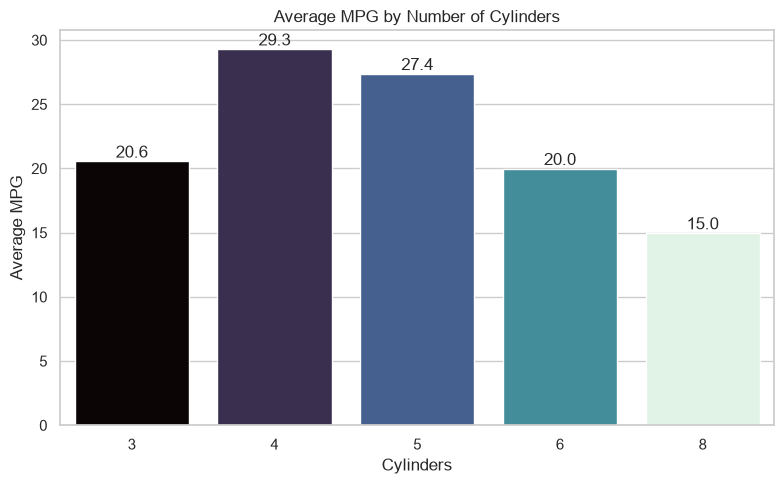

cylinders
3      4
4    199
5      3
6     83
8    103
Name: count, dtype: int64


In [67]:
cylinder_mpg = df_clean.groupby('cylinders')['mpg'].mean().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=cylinder_mpg.index, y=cylinder_mpg.values, hue=cylinder_mpg.index, palette='mako', legend=False, ax=ax)
ax.set_title('Average MPG by Number of Cylinders')
ax.set_xlabel('Cylinders')
ax.set_ylabel('Average MPG')
for i, v in enumerate(cylinder_mpg.values): ax.text(i, v + 0.3, f'{v:.1f}', ha='center')
plt.tight_layout()
plt.show()

print(df_clean['cylinders'].value_counts().sort_index())

Trennya turun hampir monoton: 3-cylinder rata-rata mpg-nya paling tinggi, terus turun sampai 8-cylinder paling boros. Perlu dicatat, mobil 3 dan 5 cylinder jumlahnya dikit banget (lihat `value_counts()`), jadi rata-ratanya kurang reliable dibanding 4/6/8-cylinder yang datanya lebih banyak. Bar chart ini nguatin argumen kalau "ukuran mesin" (cylinders, displacement, atau weight) adalah driver utama fuel efficiency.

## Stage 4, Contextual Interpretation

### Faktor apa yang paling kuat memprediksi fuel efficiency?

Dari semua analisis di atas, menurut saya **weight** yang paling kuat memprediksi mpg dibanding fitur lain. Correlation-nya emang paling negatif ke mpg (-0.832), sedikit lebih kuat dari displacement (-0.805) dan horsepower (-0.778), meski selisihnya nggak terlalu jauh jadi bukan berarti dua fitur itu nggak relevan sama sekali.

Yang bikin saya lebih yakin, polanya konsisten muncul di analisis lain juga. USA yang mobilnya rata-rata lebih berat (banyak V8, body besar) mpg-nya paling rendah, Jepang yang mobilnya lebih ringan mpg-nya paling tinggi (Plot 2). Di scatter weight-mpg (Plot 3) dan pairplot (Plot 5), hue cylinders juga nunjukin pola serupa, mobil cylinder banyak cenderung lebih berat, jadi kemungkinan pengaruh cylinders ke mpg itu lewat weight, bukan efek independen. Bar chart cylinders (Plot 6) juga ke arah yang sama.

Satu hal yang perlu diinget, weight, displacement, dan horsepower saling berkorelasi tinggi (multikolinearitas yang saya bahas di Plot 4), jadi agak susah misahin mana yang benar-benar "penyebab" dan mana yang cuma numpang lewat karena korelasi antar sesama fitur. Tapi dari kelima cara liatnya (correlation, boxplot, scatter, pairplot, barplot), weight yang sinyalnya paling konsisten, jadi itu jawaban saya.

decade
1970    21.084365
1980    31.975294
Name: mpg, dtype: float64


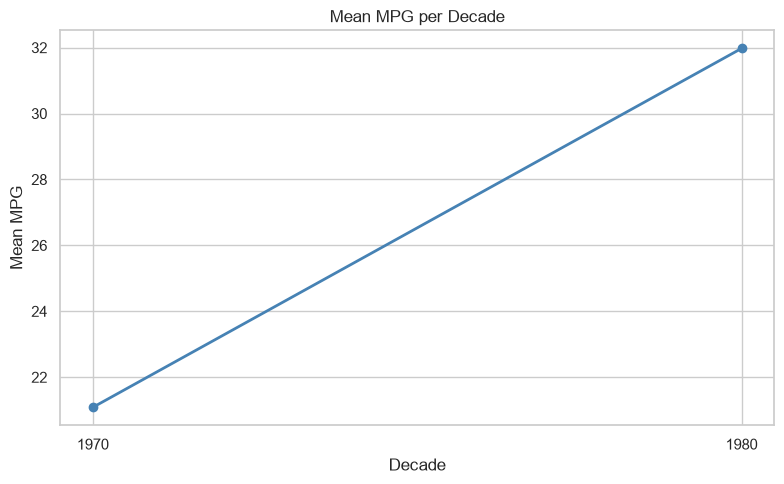

In [68]:
df_clean['decade'] = (df_clean['model_year'] // 10 * 10) + 1900
decade_mpg = df_clean.groupby('decade')['mpg'].mean()
print(decade_mpg)

fig, ax = plt.subplots(figsize=(8, 5))
decade_mpg.plot(kind='line', marker='o', ax=ax, color='steelblue', linewidth=2)
ax.set_title('Mean MPG per Decade')
ax.set_xlabel('Decade')
ax.set_ylabel('Mean MPG')
ax.set_xticks(decade_mpg.index)
plt.tight_layout()
plt.show()

Mean mpg naik cukup jauh dari dekade 1970an (21.08) ke 1980an (31.98), meski perlu dicatat dataset ini cuma nyakup model_year 70-82, jadi "1980an" di sini sebenernya cuma 2-3 tahun awal dekade itu, bukan sepuluh tahun penuh. Kenaikannya kemungkinan terkait krisis minyak taun 70an yang bikin orang mulai nyari mobil lebih irit, ditambah makin banyak mobil Jepang yang lebih kecil masuk pasar Amerika di periode itu (konsisten sama Plot 2, Jepang mpg-nya paling tinggi across origin). Saya nggak nyari sumber spesifik soal regulasi bahan bakar taun segitu, jadi ini lebih ke dugaan berdasarkan konteks umum, bukan sesuatu yang saya verifikasi ke datanya langsung.

## Bonus 1, Normal Equation from Scratch

In [69]:
X_weight = df_clean['weight'].to_numpy().reshape(-1, 1).astype(float)
y = df_clean['mpg'].to_numpy().astype(float)
X_bias = np.hstack([np.ones((X_weight.shape[0], 1)), X_weight])
theta = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ y
intercept, slope = theta

print(f"Intercept: {intercept:.6f}")
print(f"Slope: {slope:.6f}")

Intercept: 46.216525
Slope: -0.007647


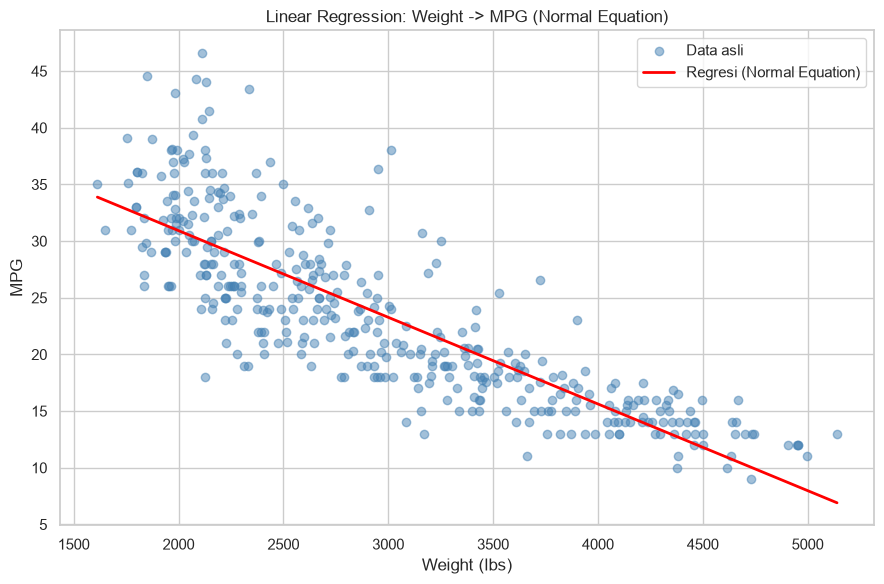

In [70]:
y_pred = X_bias @ theta

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(X_weight, y, alpha=0.5, color='steelblue', label='Data asli')
xline = np.linspace(X_weight.min(), X_weight.max(), 100).reshape(-1, 1)
xline_bias = np.hstack([np.ones((100, 1)), xline])
ax.plot(xline, xline_bias @ theta, color='red', linewidth=2, label='Regresi (Normal Equation)')
ax.set_title('Linear Regression: Weight -> MPG (Normal Equation)')
ax.set_xlabel('Weight (lbs)')
ax.set_ylabel('MPG')
ax.legend()
plt.tight_layout()
plt.show()

In [71]:
rmse = np.sqrt(np.mean((y_pred - y) ** 2))
print(f"RMSE: {rmse:.4f}")

RMSE: 4.3216


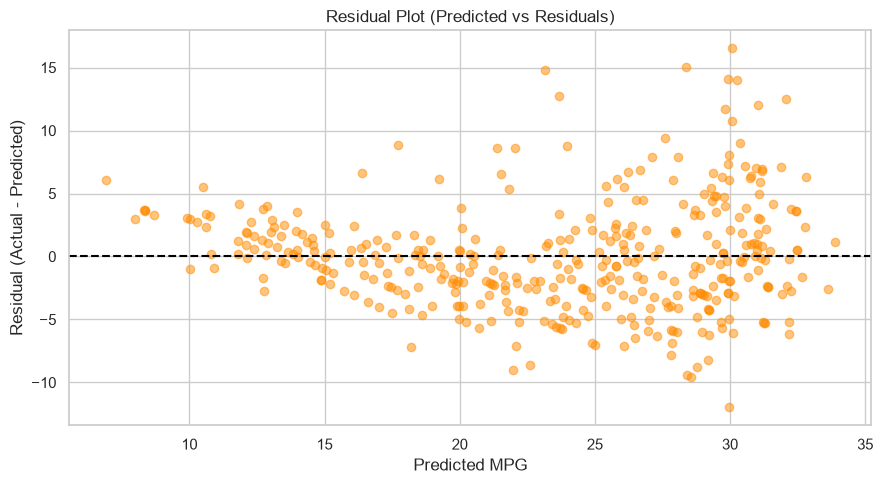

In [72]:
residuals = y - y_pred

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(y_pred, residuals, alpha=0.5, color='darkorange')
ax.axhline(0, color='black', linestyle='--', linewidth=1.5)
ax.set_title('Residual Plot (Predicted vs Residuals)')
ax.set_xlabel('Predicted MPG')
ax.set_ylabel('Residual (Actual - Predicted)')
plt.tight_layout()
plt.show()

Ini di luar instruksi soal, saya coba tambahin residual plot sendiri buat lihat apakah errornya acak atau ada pola. Ternyata keliatan agak melengkung, bukan tersebar acak di sekitar garis nol, jadi kemungkinan hubungan weight-mpg emang nggak murni linear. Mungkin ini juga salah satu alasan RMSE-nya masih 4.32 (lumayan gede buat cuma satu fitur), meskipun saya belum coba bandingin sama model non-linear buat mastiin dugaan ini.

In [73]:
z_polyfit = np.polyfit(df_clean['weight'], df_clean['mpg'], 1)
print("Slope, Intercept dari np.polyfit():", z_polyfit)
print(f"Slope, Intercept dari Normal Equation: {slope:.6f}, {intercept:.6f}")

Slope, Intercept dari np.polyfit(): [-7.64734254e-03  4.62165245e+01]
Slope, Intercept dari Normal Equation: -0.007647, 46.216525


Hasil Normal Equation sama persis sama `np.polyfit()` (slope -0.00765, intercept 46.22). Ini emang sesuai ekspektasi, karena keduanya sama-sama nyari solusi closed-form buat least-squares regression, cuma beda implementasi doang (satu manual menggunakan matrix inverse, satu menggunakan fungsi bawaan NumPy).

## Bonus 2, PCA from Scratch

In [74]:
def quick_pca_variance(mat):
    Xt = mat - mat.mean(axis=0)
    cov = (Xt.T @ Xt) / (Xt.shape[0] - 1)
    eigvals = np.linalg.eigvalsh(cov)[::-1]
    return eigvals / eigvals.sum()

evr_raw = quick_pca_variance(X)
evr_z = quick_pca_variance(X_z)

print("Explained variance ratio menggunakan X mentah   :", evr_raw.round(4))
print("Explained variance ratio menggunakan X standard :", evr_z.round(4))

Explained variance ratio menggunakan X mentah   : [9.976e-01 2.100e-03 4.000e-04 0.000e+00 0.000e+00]
Explained variance ratio menggunakan X standard : [0.7854 0.1424 0.0451 0.0166 0.0105]


Menggunakan `X` mentah, PC1 sendirian nyerap hampir semua variance (>99%), itu bukan struktur data yang sebenarnya, cuma ngikutin skala satuan `weight` yang emang paling besar angkanya dibanding fitur lain. Makanya PCA di bawah ini saya jalanin di atas `X_z` (data yang sudah distandardisasi dari Stage 2), biar komponennya representasi hubungan antar fitur, bukan sekadar urutan skala kolom.

In [75]:
X_tilde = X_z - X_z.mean(axis=0)
cov_matrix = (X_tilde.T @ X_tilde) / (X_tilde.shape[0] - 1)
eigvals, eigvecs = np.linalg.eigh(cov_matrix)
sort_idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[sort_idx]
eigvecs = eigvecs[:, sort_idx]
V2 = eigvecs[:, :2]
Z = X_tilde @ V2
explained_variance_ratio = eigvals / eigvals.sum()

print("Eigenvalues (terurut):", eigvals.round(4))
print("Explained variance ratio PC1:", round(explained_variance_ratio[0], 4))
print("Explained variance ratio PC2:", round(explained_variance_ratio[1], 4))
print("Total explained variance (PC1+PC2):", round(explained_variance_ratio[:2].sum(), 4))

Eigenvalues (terurut): [3.9368 0.7138 0.2262 0.0831 0.0529]
Explained variance ratio PC1: 0.7854
Explained variance ratio PC2: 0.1424
Total explained variance (PC1+PC2): 0.9278


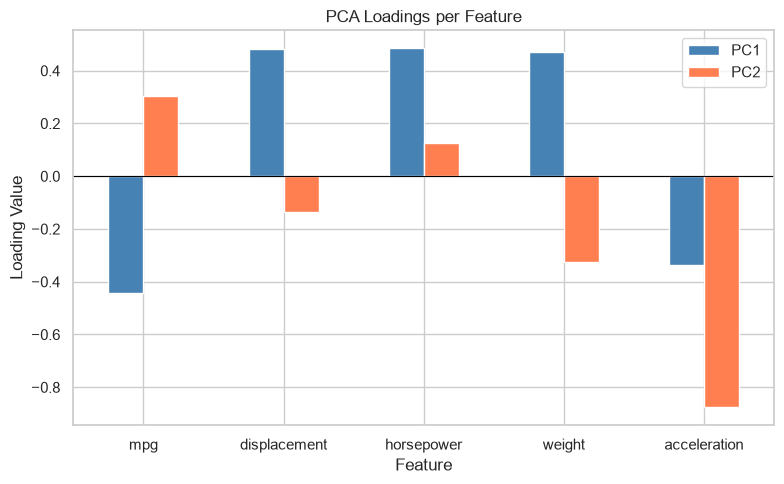

,PC1,PC2
mpg,-0.444,0.304
displacement,0.483,-0.135
horsepower,0.484,0.124
weight,0.471,-0.326
acceleration,-0.335,-0.876


In [76]:
loadings = pd.DataFrame(V2, index=feature_cols, columns=['PC1', 'PC2'])

fig, ax = plt.subplots(figsize=(8, 5))
loadings.plot(kind='bar', ax=ax, color=['steelblue', 'coral'])
ax.set_title('PCA Loadings per Feature')
ax.set_xlabel('Feature')
ax.set_ylabel('Loading Value')
ax.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

loadings.round(3)

PC1 didominasi `displacement`, `horsepower`, `weight` (semuanya positif, sekitar 0.47-0.48) berlawanan arah sama `mpg` dan `acceleration` (negatif). Jadi PC1 kurang lebih sumbu "ukuran & tenaga mesin vs efisiensi". PC2 didominasi `acceleration` (-0.876, jauh lebih besar dari fitur lain), lebih ke arah "seberapa cepat akselerasinya", agak independen dari ukuran mesin.

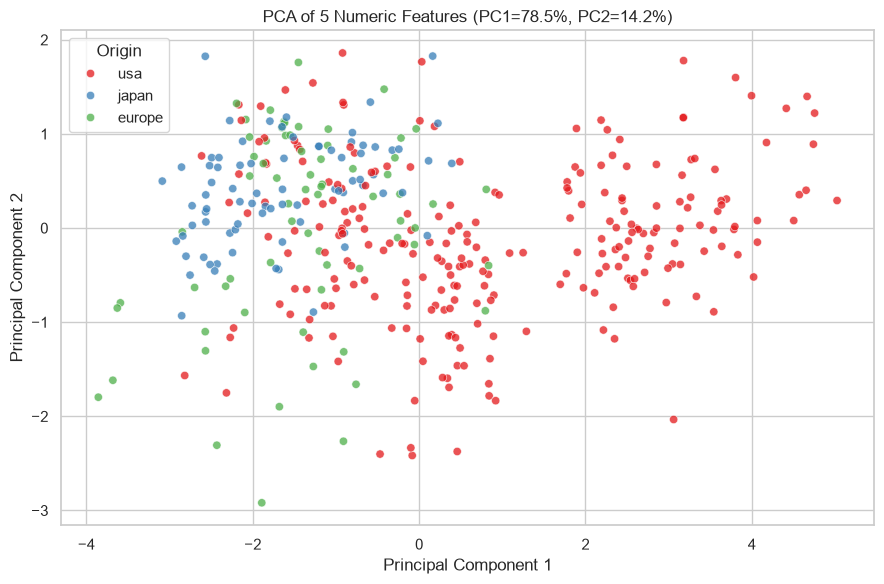

In [77]:
pca_df = pd.DataFrame(Z, columns=['PC1', 'PC2'])
pca_df['origin'] = df_clean['origin'].to_numpy()

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='origin', palette='Set1', alpha=0.75, ax=ax)
ax.set_title(f'PCA of 5 Numeric Features (PC1={explained_variance_ratio[0]*100:.1f}%, PC2={explained_variance_ratio[1]*100:.1f}%)')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.legend(title='Origin')
plt.tight_layout()
plt.show()

PC1 sendirian nangkep 78.5% variance, PC1+PC2 gabungan 92.8% dari total variance 5 fitur asli.

Dari plot, mobil USA (biru) cenderung ngumpul di PC1 tinggi, Jepang dan Eropa lebih ke kiri. Konsisten sama loading plot sebelumnya (PC1 tinggi = mesin gede + boros) dan sama temuan boxplot/violin origin di Plot 2 kalau USA paling boros mpg-nya.

## Bonus 3, Reusable EDA Class

In [78]:
class DatasetProfiler:
    def __init__(self, df, target_col):
        self.df = df
        self.target_col = target_col
        self.numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    def summary_stats(self):
        rows = []
        for col in self.numeric_cols:
            arr = self.df[col].to_numpy(dtype=float)
            mean = np.mean(arr)
            median = np.median(arr)
            std = np.std(arr, ddof=1)
            q1, q3 = np.percentile(arr, [25, 75])
            iqr = q3 - q1
            lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
            n_out = int(np.sum((arr < lo) | (arr > hi)))
            rows.append({'feature': col, 'mean': round(mean, 2), 'median': round(median, 2), 'std': round(std, 2), 'IQR': round(iqr, 2), 'outlier_count': n_out})
        return pd.DataFrame(rows).set_index('feature')

    def correlation_report(self):
        corr_series = self.df[self.numeric_cols].corr()[self.target_col]
        corr_series = corr_series.drop(self.target_col)
        return corr_series.sort_values(ascending=False)

    def plot_dashboard(self, category_col=None):
        fig, axes = plt.subplots(2, 2, figsize=(13, 10))
        sns.histplot(self.df[self.target_col], kde=True, ax=axes[0, 0], color='steelblue')
        axes[0, 0].set_title(f'Distribution of {self.target_col}')
        if category_col is not None and category_col in self.df.columns:
            sns.boxplot(data=self.df, x=category_col, y=self.target_col, hue=category_col, palette='Set2', legend=False, ax=axes[0, 1])
            axes[0, 1].set_title(f'{self.target_col} by {category_col}')
        else:
            axes[0, 1].axis('off')
            axes[0, 1].set_title('No category column provided')

        corr_matrix = self.df[self.numeric_cols].corr()
        sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1, 0])
        axes[1, 0].set_title('Correlation Heatmap')

        strongest_feat = self.correlation_report().abs().idxmax()
        sns.scatterplot(data=self.df, x=strongest_feat, y=self.target_col, alpha=0.6, ax=axes[1, 1], color='darkorange')
        axes[1, 1].set_title(f'{strongest_feat} vs {self.target_col} (strongest correlation)')

        plt.tight_layout()
        plt.show()

    def generate_report(self):
        corr = self.correlation_report()
        summary = self.summary_stats()
        report = {
            'target_col': self.target_col,
            'n_rows': int(self.df.shape[0]),
            'numeric_columns': self.numeric_cols,
            'strongest_positive_corr_feature': corr.idxmax(),
            'strongest_positive_corr_value': round(float(corr.max()), 4),
            'strongest_negative_corr_feature': corr.idxmin(),
            'strongest_negative_corr_value': round(float(corr.min()), 4),
            'summary_stats': summary.reset_index().to_dict(orient='records')
        }
        return report

In [79]:
profiler = DatasetProfiler(df_clean, target_col='mpg')

print("summary_stats(): ")
display(profiler.summary_stats())

print("\ncorrelation_report(): ")
print(profiler.correlation_report())

summary_stats(): 


,mean,median,std,IQR,outlier_count
feature,,,,,
mpg,23.45,22.75,7.81,12.00,0
cylinders,5.47,4.00,1.71,4.00,0
displacement,194.41,151.00,104.64,170.75,0
horsepower,104.47,93.50,38.49,51.00,10
weight,2977.58,2803.50,849.40,1389.50,0
acceleration,15.54,15.50,2.76,3.25,11
model_year,75.98,76.00,3.68,6.00,0
decade,1972.17,1970.00,4.13,0.00,85



correlation_report(): 
model_year      0.580541
decade          0.575757
acceleration    0.423329
cylinders      -0.777618
horsepower     -0.778427
displacement   -0.805127
weight         -0.832244
Name: mpg, dtype: float64


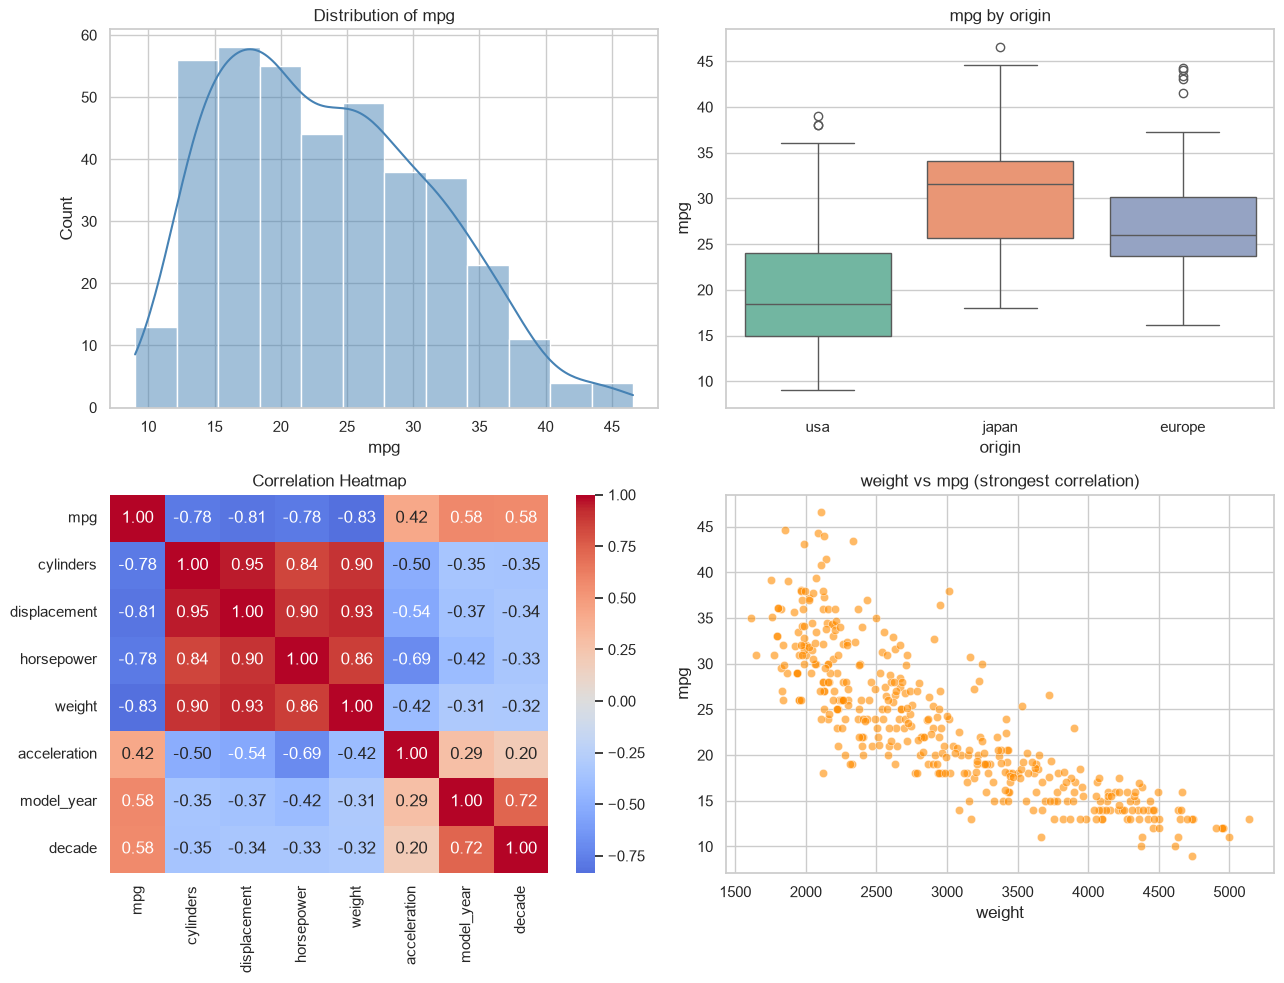

In [80]:
profiler.plot_dashboard(category_col='origin')

In [81]:
import json
report = profiler.generate_report()
print(json.dumps(report, indent=2))

{
  "target_col": "mpg",
  "n_rows": 392,
  "numeric_columns": [
    "mpg",
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year",
    "decade"
  ],
  "strongest_positive_corr_feature": "model_year",
  "strongest_positive_corr_value": 0.5805,
  "strongest_negative_corr_feature": "weight",
  "strongest_negative_corr_value": -0.8322,
  "summary_stats": [
    {
      "feature": "mpg",
      "mean": 23.45,
      "median": 22.75,
      "std": 7.81,
      "IQR": 12.0,
      "outlier_count": 0
    },
    {
      "feature": "cylinders",
      "mean": 5.47,
      "median": 4.0,
      "std": 1.71,
      "IQR": 4.0,
      "outlier_count": 0
    },
    {
      "feature": "displacement",
      "mean": 194.41,
      "median": 151.0,
      "std": 104.64,
      "IQR": 170.75,
      "outlier_count": 0
    },
    {
      "feature": "horsepower",
      "mean": 104.47,
      "median": 93.5,
      "std": 38.49,
      "IQR": 51.0,
      "outlier_count": 10

Satu catatan dari `summary_stats()` di atas adalah kolom `decade` keluar `outlier_count = 85`, tapi itu bukan berarti ada 85 mobil yang datanya aneh. `decade` cuma punya 2 nilai unik (1970 dan 1980, karena dataset ini cuma nyakup model_year 70-82), jadi Q1 = Q3 = 1970 (IQR = 0), dan metode IQR x1.5 otomatis nge flag semua baris yang bukan 1970 (85 mobil dari dekade 1980) sebagai outlier. Ini artefak dari nerapin metode outlier IQR ke variabel yang isinya cuma segelintir nilai diskrit, perlu diinget kalau `DatasetProfiler` ini di reuse ke dataset lain yang punya kolom numerik-tapi-sebenernya-kategorikal kayak gini.

## Refleksi Personal

Bagian yang paling nempel buat saya sebenernya bukan bagian ngoding (rumus-rumusnya kan udah ada di handbook, tinggal translate ke NumPy), tapi pas PCA ternyata kalau lupa standardize dulu, hasilnya kelihatan jalan (nggak ada error, angka keluar, plot muncul) padahal isinya cuma ngikutin skala kolom doang. Itu jenis kesalahan yang paling bikin ribet. Dari sisi insight datanya sendiri, nggak ada yang bikin kaget-kaget banget, weight jadi prediktor utama itu emang cocok sama intuisi fisika dasar (makin berat, makin butuh energi buat gerak). Yang lumayan menarik itu pola multikolinearitas weight-displacement-horsepower, bisa jadi masalah kalau nanti ketiganya dipaksa masuk bareng ke satu model regresi.